<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/Logistic_Regression_German_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",200)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df1 = '/content/drive/MyDrive/Dataset/German_Credit.csv'

## Read Dataset

In [ ]:
df = pd.read_csv(df1)

## Data Overview

### View the first and last 5 rows of the dataset.

In [ ]:
df.head()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


In [ ]:
df.tail()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


## Understand the shape of the dataset

In [ ]:
df.shape

(1000, 8)

## Chack the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


## Chacking for duplicates values

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [ ]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset

## Checking for missing values

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Risk,0
Purpose,0


- there are no missing values in the dataset

## Statistical summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Risk,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


In [ ]:
# making a list of all categorical variable
category_col = [
    "Sex",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk"
    ]

for column in category_col:
  print(df[column].value_counts())
  print("_"*40)

Sex
male      690
female    310
Name: count, dtype: int64
________________________________________
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
________________________________________
Checking account
moderate    472
little      465
rich         63
Name: count, dtype: int64
________________________________________
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
________________________________________
Risk
0    700
1    300
Name: count, dtype: int64
________________________________________


## Exploratory Data Analysis (EDA) Summary

- ***Note: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the appendix section.***

## ***Histplot***

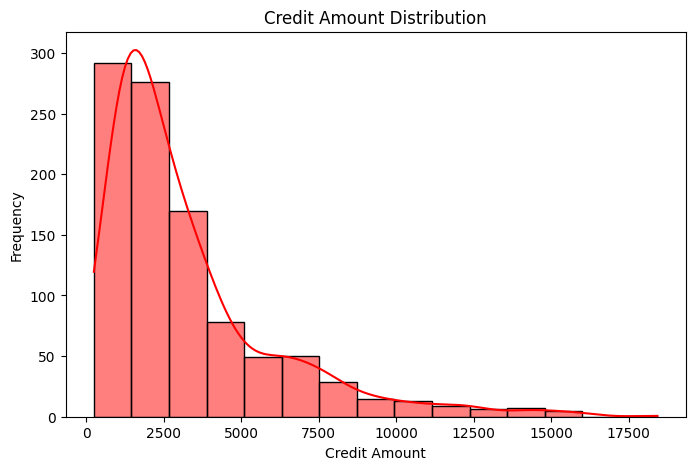

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Credit amount"],kde = True,bins = 15,color = "red")
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

## ***Scatter Plot***

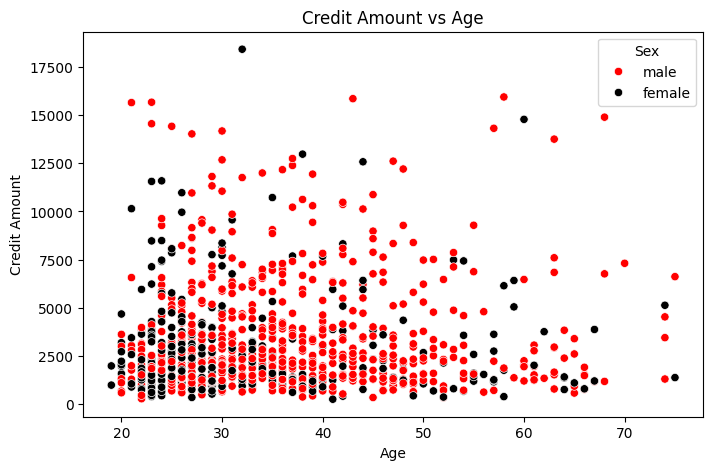

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df,x = "Age", y = "Credit amount", hue = "Sex", palette={'male':'red', 'female':'black'})
plt.title("Credit Amount vs Age")
plt.xlabel("Age")
plt.ylabel("Credit Amount")
plt.show()

## ***Box Plot***

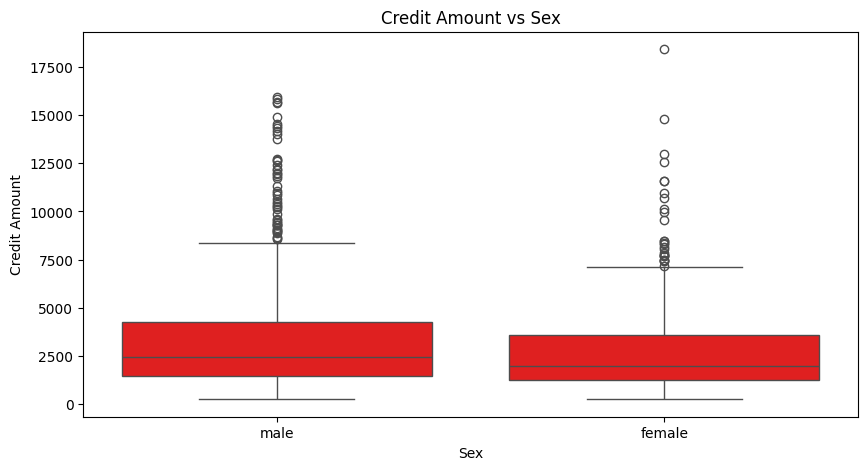

In [ ]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = "Sex", y = "Credit amount",color = "red")
plt.title("Credit Amount vs Sex")
plt.xlabel("Sex")
plt.ylabel("Credit Amount")
plt.show()

## ***Heat Map***

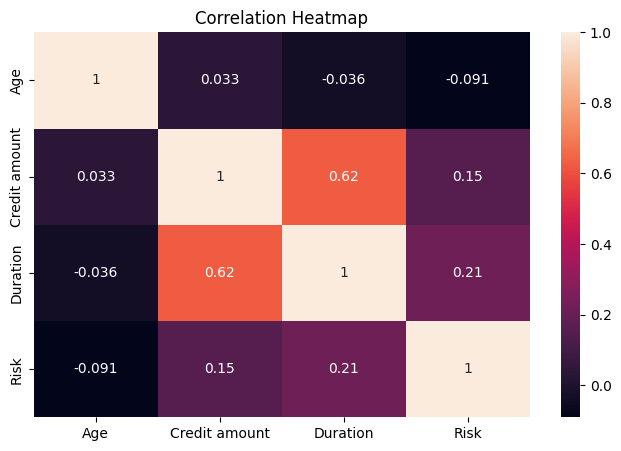

In [ ]:
plt.figure(figsize = (8,5))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title("Correlation Heatmap")
plt.show()

## ***Pair Plot***

<Figure size 1000x500 with 0 Axes>

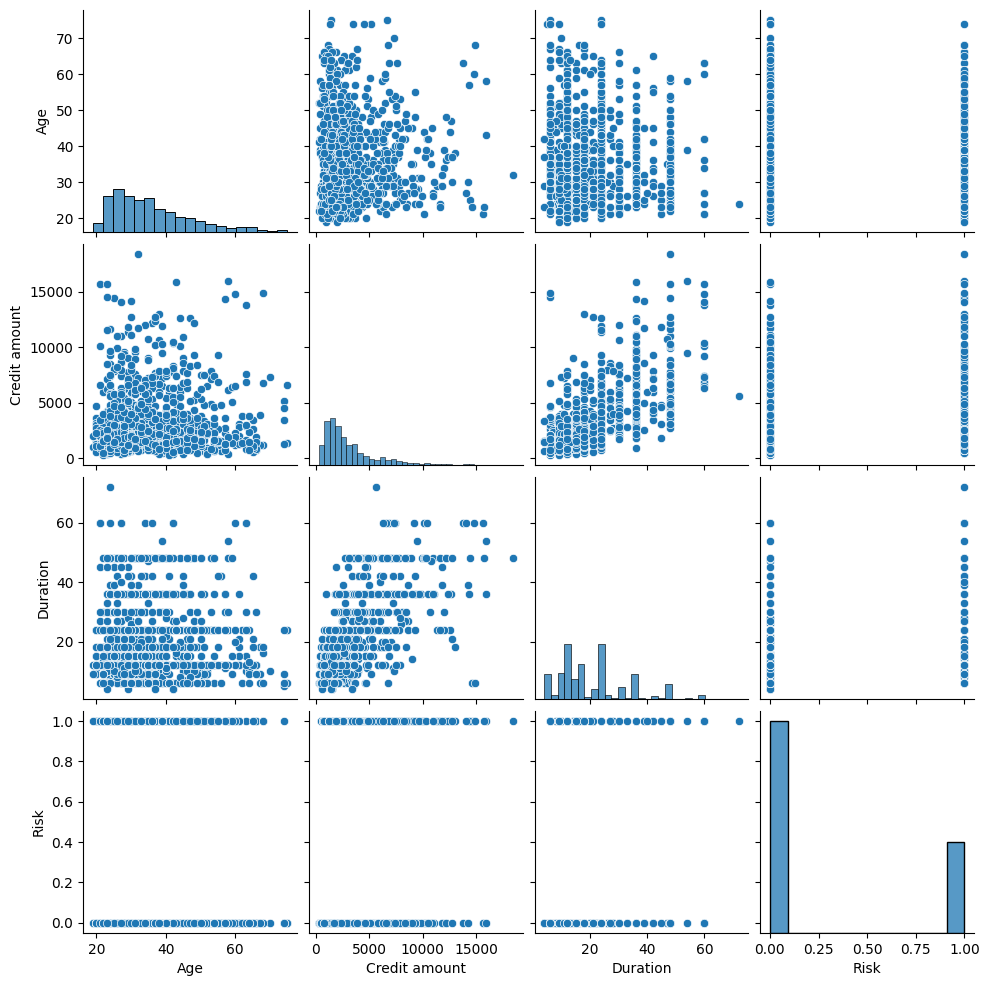

In [ ]:
plt.figure(figsize=(10,5))
sns.pairplot(df)
plt.show()

<Axes: xlabel='Credit amount', ylabel='Count'>

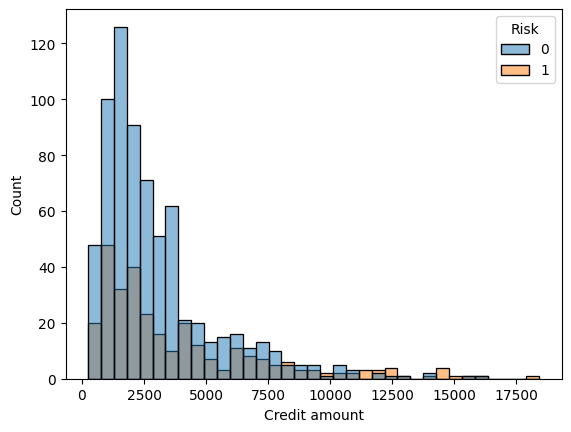

In [ ]:
sns.histplot(df, x='Credit amount', hue = "Risk")

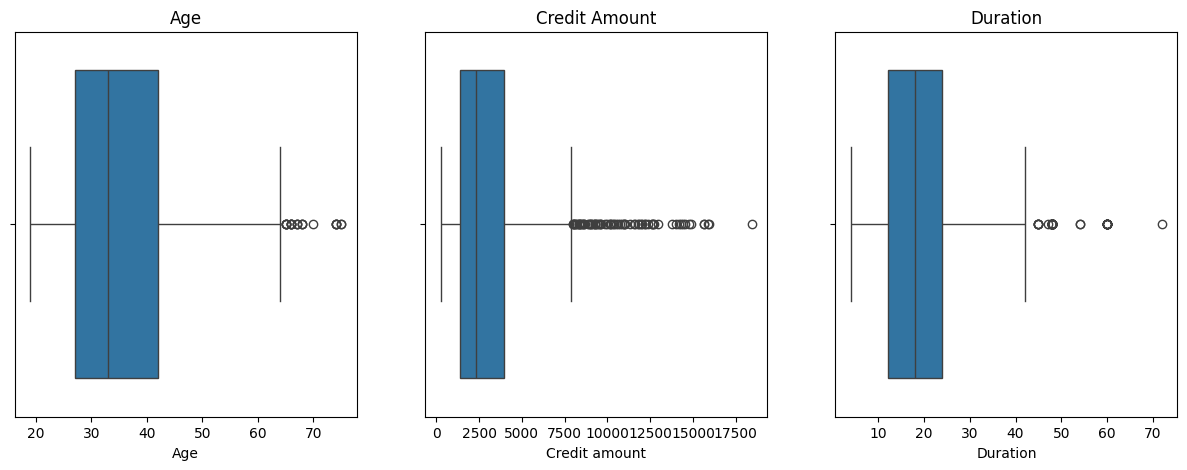

In [ ]:
plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
sns.boxplot(data = df,x = "Age")
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(data = df, x = "Credit amount")
plt.title("Credit Amount")

plt.subplot(1,3,3)
sns.boxplot(data = df, x = "Duration")
plt.title("Duration")
plt.show()

In [ ]:
df.columns

Index(['Age', 'Sex', 'Saving accounts', 'Checking account', 'Credit amount',
       'Duration', 'Risk', 'Purpose'],
      dtype='object')

In [ ]:
df['Duration'] = df['Duration']/12

In [ ]:
X = df.drop(columns = "Risk", axis = 1)
Y = df["Risk"]

In [ ]:
X = pd.get_dummies(X, drop_first = True)
X.head()

,Age,Credit amount,Duration,Sex_male,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1169,0.5,True,False,False,False,False,False,False,False,False,False,True,False,False
1,22,5951,4.0,False,False,False,False,True,False,False,False,False,False,True,False,False
2,49,2096,1.0,True,False,False,False,False,False,False,False,True,False,False,False,False
3,45,7882,3.5,True,False,False,False,False,False,False,False,False,True,False,False,False
4,53,4870,2.0,True,False,False,False,False,False,True,False,False,False,False,False,False


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
model = LogisticRegression(random_state = 42)
model.fit(X_train, Y_train)

LogisticRegression(random_state=42)

In [ ]:
threshold = 0.5

pred_temp = (model.predict_proba(X_test))[:, 1] > threshold
pred = np.round(pred_temp)

acc = accuracy_score(Y_test, pred)
recall = recall_score(Y_test, pred)
precision = precision_score(Y_test, pred)
f1 = f1_score(Y_test, pred)

df_perf = pd.DataFrame(
    {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1},
    index=[0],
)

print(df_perf)

   Accuracy    Recall  Precision        F1
0     0.715  0.135593   0.571429  0.219178


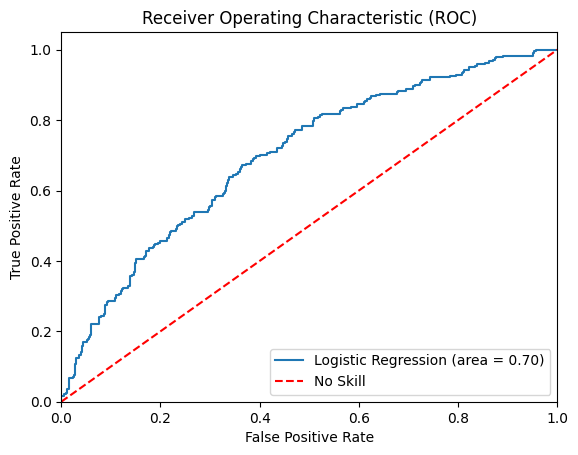

In [ ]:
logit_roc_auc = roc_auc_score(Y_train, model.predict_proba(X_train)[:,1])
FPR, TPR, thresholds = roc_curve(Y_train, model.predict_proba(X_train)[:,1])
plt.figure()
plt.plot(FPR, TPR, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--',label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()